# INTEGRATE Timing Analysis Example

This example demonstrates how to perform comprehensive timing analysis of the INTEGRATE workflow
using the built-in timing_compute() and timing_plot() functions. 

The timing analysis benchmarks four main components:
1. Prior model generation (layered geological models)
2. Forward modeling using GA-AEM electromagnetic simulation  
3. Rejection sampling for Bayesian inversion
4. Posterior statistics computation

Results are automatically saved and comprehensive plots are generated showing:
- Performance scaling with dataset size and processor count
- Speedup analysis and parallel efficiency
- Comparisons with traditional least squares and MCMC methods
- Component-wise timing breakdowns

In [1]:
try:
    # Check if the code is running in an IPython kernel (which includes Jupyter notebooks)
    get_ipython()
    # If the above line doesn't raise an error, it means we are in a Jupyter environment
    # Execute the magic commands using IPython's run_line_magic function
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
except:
    # If get_ipython() raises an error, we are not in a Jupyter environment
    pass

In [2]:
import integrate as ig
import numpy as np
import matplotlib.pyplot as plt
import time

# Check if parallel computations can be performed
parallel = ig.use_parallel(showInfo=1)

Notebook detected. Parallel processing is OK.


## Quick Timing Test

This example runs a quick timing test with a small subset of dataset sizes 
and processor counts to demonstrate the timing functions.

In [3]:
print("# Running Quick Timing Test")
print("="*50)

# Define test parameters - small arrays for quick demonstration
N_arr_quick = [100, 1000, 10000]  # Small dataset sizes for quick test
Nproc_arr_quick = [1, 2, 4, 8]     # Limited processor counts

# Run timing computation
timing_file = ig.timing_compute(N_arr=N_arr_quick, Nproc_arr=Nproc_arr_quick)

print(f"\nTiming results saved to: {timing_file}")

# Running Quick Timing Test
Notebook detected. Parallel processing is OK.
# TIMING TEST
Hostname (system): PP (Linux) 
Number of processors: 24
Using data file: DAUGAARD_AVG.h5
Using GEX file: TX07_20231016_2x4_RC20-33.gex
Testing on 3 data sets of size(s): [100, 1000, 10000]
Testing on 4 sets of core(s): [1, 2, 4, 8]
Rejection sampling backend: numpy
Writing results to timing_PP-Linux-24core_Nproc4_N3_numpy.npz 
TIMING: N=100, Ncpu=1, Ncpu_min=0
Using file_basename=TX07_20231016_2x4_RC20-33
prior_data_gaaem: Using 1 parallel threads.


gatdaem1d:   0%|                                                                                                                             | 0/100 [00:00<?, ?it/s]

gatdaem1d:  58%|███████████████████████████████████████████████████████████████████▎                                                | 58/100 [00:01<00:00, 57.92it/s]

prior_data_gaaem: Time=  1.9s/100 soundings. 19.5ms/sounding, 51.3it/s


Rejection Sampling:   0%|                                                                                                                  | 0/11693 [00:00<?, ?it/s]

...

M2-continuous:  63%|███████████████████████████████████████████████████████████████████                                       | 7393/11693 [00:04<00:02, 1850.02it/s]

M2-continuous:  79%|███████████████████████████████████████████████████████████████████████████████████▊                      | 9244/11693 [00:05<00:01, 1837.82it/s]

M2-continuous:  95%|███████████████████████████████████████████████████████████████████████████████████████████████████▌     | 11082/11693 [00:06<00:00, 1820.91it/s]

M3-continuous:   0%|                                                                                                                       | 0/11693 [00:00<?, ?it/s]


Timing results saved to: timing_PP-Linux-24core_Nproc4_N3_numpy.npz


## Generate Comprehensive Timing Plots

The timing_plot() function generates multiple analysis plots automatically


# Generating Timing Plots
Plotting timing results from timing_PP-Linux-24core_Nproc4_N3_numpy.npz


RecursionError: maximum recursion depth exceeded

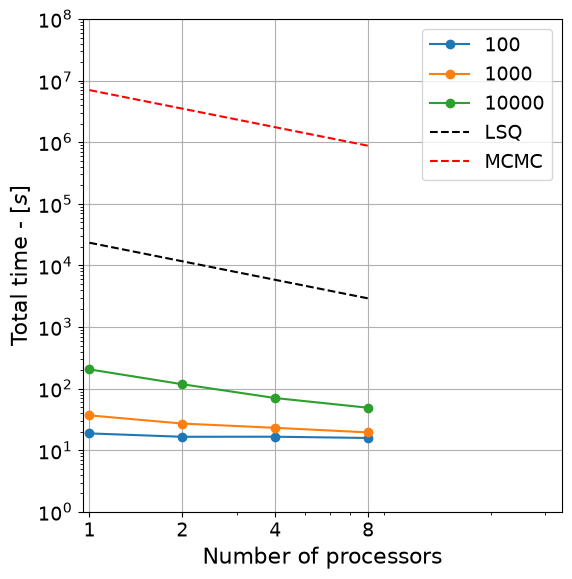

In [4]:
print("\n# Generating Timing Plots")
print("="*50)

# Generate comprehensive timing plots
ig.timing_plot(f_timing=timing_file)

print(f"Timing plots generated with prefix: {timing_file.split('.')[0]}")
print("Generated plots include:")
print("- Total execution time analysis")
print("- Forward modeling performance and speedup")
print("- Rejection sampling scaling analysis") 
print("- Posterior statistics performance")
print("- Cumulative time breakdowns")

## Medium Scale Timing Test

This example shows how to run a more comprehensive timing test with larger datasets.
Uncomment the code below to run a medium-scale test (takes longer to complete).

In [5]:
# Uncomment the block below for medium-scale timing test
"""
print("\n# Running Medium Scale Timing Test")
print("="*50)

# Define medium-scale test parameters  
N_arr_medium = [100, 500, 1000, 5000, 10000]  # Medium dataset sizes
Nproc_arr_medium = [1, 2, 4, 8]               # More processor counts

# Run timing computation
timing_file_medium = ig.timing_compute(N_arr=N_arr_medium, Nproc_arr=Nproc_arr_medium)

print(f"Medium-scale timing results saved to: {timing_file_medium}")

# Generate plots
ig.timing_plot(f_timing=timing_file_medium)
print(f"Medium-scale timing plots generated with prefix: {timing_file_medium.split('.')[0]}")
"""

'\nprint("\n# Running Medium Scale Timing Test")\nprint("="*50)\n\n# Define medium-scale test parameters  \nN_arr_medium = [100, 500, 1000, 5000, 10000]  # Medium dataset sizes\nNproc_arr_medium = [1, 2, 4, 8]               # More processor counts\n\n# Run timing computation\ntiming_file_medium = ig.timing_compute(N_arr=N_arr_medium, Nproc_arr=Nproc_arr_medium)\n\nprint(f"Medium-scale timing results saved to: {timing_file_medium}")\n\n# Generate plots\nig.timing_plot(f_timing=timing_file_medium)\nprint(f"Medium-scale timing plots generated with prefix: {timing_file_medium.split(\'.\')[0]}")\n'

## Full Scale Timing Test  

For production timing analysis, you can run the full test with the default parameters.
This will test a wide range of dataset sizes and all available processor counts.

In [6]:
# Uncomment the block below for full-scale timing test (takes significant time)
"""
print("\n# Running Full Scale Timing Test")
print("="*50)

# Run with default parameters (comprehensive test)
timing_file_full = ig.timing_compute()  # Uses default N_arr and Nproc_arr

print(f"Full-scale timing results saved to: {timing_file_full}")

# Generate comprehensive plots
ig.timing_plot(f_timing=timing_file_full)
print(f"Full-scale timing plots generated with prefix: {timing_file_full.split('.')[0]}")
"""

'\nprint("\n# Running Full Scale Timing Test")\nprint("="*50)\n\n# Run with default parameters (comprehensive test)\ntiming_file_full = ig.timing_compute()  # Uses default N_arr and Nproc_arr\n\nprint(f"Full-scale timing results saved to: {timing_file_full}")\n\n# Generate comprehensive plots\nig.timing_plot(f_timing=timing_file_full)\nprint(f"Full-scale timing plots generated with prefix: {timing_file_full.split(\'.\')[0]}")\n'

## Custom Timing Configuration

You can also customize the timing test for specific scenarios

In [7]:
print("\n# Example: Custom Timing Configuration")
print("="*50)

# Example: Focus on specific dataset sizes of interest
N_arr_custom = [1000, 5000, 10000]  # Focus on medium-large datasets
Nproc_arr_custom = [1, 4, 8]        # Test specific processor counts

print(f"Custom test configuration:")
print(f"Dataset sizes: {N_arr_custom}")  
print(f"Processor counts: {Nproc_arr_custom}")
print(f"This configuration tests {len(N_arr_custom)} × {len(Nproc_arr_custom)} = {len(N_arr_custom) * len(Nproc_arr_custom)} combinations")

# Uncomment to run custom timing test
"""
timing_file_custom = ig.timing_compute(N_arr=N_arr_custom, Nproc_arr=Nproc_arr_custom)
ig.timing_plot(f_timing=timing_file_custom)
print(f"Custom timing analysis complete: {timing_file_custom}")
"""


# Example: Custom Timing Configuration
Custom test configuration:
Dataset sizes: [1000, 5000, 10000]
Processor counts: [1, 4, 8]
This configuration tests 3 × 3 = 9 combinations


'\ntiming_file_custom = ig.timing_compute(N_arr=N_arr_custom, Nproc_arr=Nproc_arr_custom)\nig.timing_plot(f_timing=timing_file_custom)\nprint(f"Custom timing analysis complete: {timing_file_custom}")\n'

## Understanding Timing Results

The timing analysis provides insights into:

### Performance Scaling
- How execution time varies with dataset size
- Parallel efficiency across different processor counts
- Identification of computational bottlenecks

### Component Analysis  
- Relative time spent in each workflow component
- Which components benefit most from parallelization
- Memory vs compute-bound identification

### Comparison Baselines
- Performance relative to traditional least squares methods
- Comparison with MCMC sampling approaches
- Cost-benefit analysis of different configurations

### Optimization Guidance
- Optimal processor counts for different dataset sizes
- Sweet spots for price-performance ratios
- Scaling behavior for production deployments

## Tips for Timing Analysis

1. **Start Small**: Begin with quick tests using small N_arr and Nproc_arr
2. **System Warm-up**: First runs may be slower due to system initialization
3. **Resource Monitoring**: Monitor CPU, memory usage during large tests
4. **Reproducibility**: Results may vary between runs due to system load
5. **Hardware Specific**: Results are specific to your hardware configuration
6. **Baseline Comparison**: Compare with known reference systems when possible

print("\n# Timing Analysis Complete")
print("="*50)
print("Check the generated plots for detailed performance analysis.")
print("Timing data is saved in NPZ format for further analysis if needed.")